# Functional lesion network mapping

In this tutorial, you will explore the functional network mapping functionalities of Lacuna using the CLI.

**What you'll learn**:

- Fetch a functional connectome
- Obtain voxel-level lesion network maps
- Compute ROI-wise lesion network scores

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/m-petersen/lacuna/blob/main/docs/tutorials/02-functional-network-mapping.ipynb)


## Colab

Note: Colab provides limited computational resources. While these tutorials are designed to operate within those constraints, some Lacuna functionality cannot be fully demonstrated in this environment and requires access to higher-performance computing infrastructure.

Ignore this if you run this notebook locally.

## Setup

In [ ]:
# Install Lacuna from GitHub
!pip install git+https://github.com/m-petersen/lacuna

# Install yabplot and pyvista for visualization
!pip install yabplot==0.4.0 pyvista==0.47.1

Get the tutorial data.

In [14]:
# Get tutorial data
!lacuna tutorial /tmp/tutorial_bids --force


Setting up tutorial data at: /tmp/tutorial_bids
✓ Tutorial data copied to: /tmp/tutorial_bids

The tutorial dataset includes:
  - 3 synthetic subjects (sub-01, sub-02, sub-03)
  - Binary lesion masks in MNI152NLin6Asym space
  - BIDS-style structure


## Fetch functional connectome

Functional network mapping requires a functional connectome in the form of resting-state functional MR images of a normative cohort.

Lacuna facilitates to download the [GSP1000 dataset](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/ILXIKS) which is openly available and the current standard. For the download you have to obtain an access token. For this register on [Harvard Dataverse](https://dataverse.harvard.edu/), click on your username and then API Token.

<p align="center"><img src="../../assets/method_figures/gsp1000.svg" alt="GSP1000" style="width:100%; max-width:160px;"><br>
  <em style="font-size: 0.9em; color: #666;">GSP1000 normative functional connectome</em></p>

Here, we will only fetch a test version of GSP1000 to keep the tutorial lightweight via the `--test-mode` flag. You should remove the flag for an actual analysis. Please mind that the full fetch needs ~320gb of free disk during the build (~220gb raw + ~100gb HDF5); you can delete the raw data afterwards to drop back to ~100gb. To maximize processing efficiency, store the connectome on an SSD.

In [15]:
!lacuna fetch gsp1000 \
    --output-dir /tmp/gsp1000_data \
    --api-key $DATAVERSE_API_KEY \
    --test-mode \
    --skip-checksum \
    --no-keep-original

Fetching GSP1000 functional connectome...
  Output: /tmp/gsp1000_data
  Mode: TEST (1 tarball only)


✓ GSP1000 fetch complete!
  Files: 1
  Duration: 0.0s
  Output: /tmp/gsp1000_data/processed


## Analysis

Functional network mapping seeks to identify the functional brain circuitry connecting to the lesion. Based on the connectome the average functional connectivity between the lesion and every voxel in the connectome space is quantified.

Lacuna's implementation consists of multiple steps:
1. Ensure spatial alignment.
2. Compute the lesion timeseries.
3. Compute voxel-wise statistics: Pearson correlations between the lesion timeseries and whole-brain timeseries, Fisher z, t-statistics, and optionally p-value maps and FDR-corrected p-values (Benjamini–Hochberg) and thresholded significance maps.
4. Export results as voxel maps (rmap, zmap, tmap, pmap, FDR-corrected pmap, threshold masks).

<p align="center"><img src="../../assets/method_figures/flnm_method.svg" alt="Functional network mapping method" style="width:100%; max-width:760px;"><br>
  <em style="font-size: 0.9em; color: #666;">Functional network mapping procedure shown with exemplary lesion.</em></p>

This procedure is based on the original method implemented by [Boes, Fox et al.](https://doi.org/10.1093/brain/awv228). 

Run the analysis.

In [16]:
!lacuna run fnm \
    /tmp/tutorial_bids/ \
    /tmp/outputs_fnm/ \
    --connectome-path /tmp/gsp1000_data/processed/ \
    --participant-label 01 \
    --mask-space MNI152NLin6Asym

2026-08-06 09:08:47 - lacuna.cli.main - ERROR - Failed to process sub-01: Output for sub-01_ses-01 already exists (e.g. /tmp/outputs_fnm/sub-01/ses-01/anat/method-fnm_space-MNI152NLin6Asym_desc-rmap (voxelmap)); nothing new to write. Use overwrite=True to regenerate.
2026-08-06 09:08:47 - lacuna.cli.main - WARNING - Subject processing failed, continuing...


Visualize the output

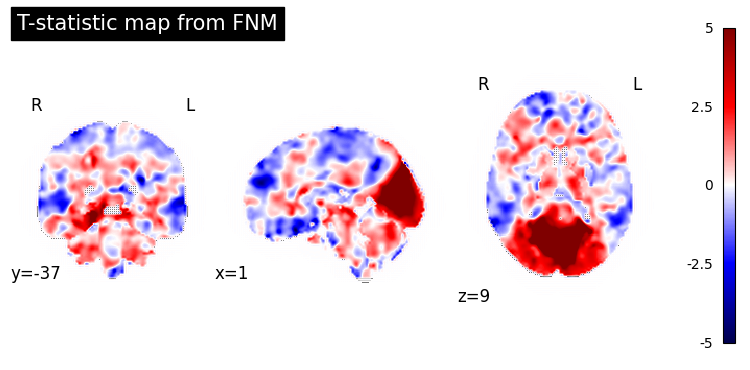

In [17]:
import nibabel as nib
from nilearn import plotting

tmap_path = '/tmp/outputs_fnm/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_method-fnm_space-MNI152NLin6Asym_desc-tmap.nii.gz'
tmap_img = nib.load(tmap_path)

plotting.plot_stat_map(tmap_img, 
                       radiological=True, 
                       title="T-statistic map from FNM",
                       draw_cross=False, 
                       colorbar=True,
                       cmap='seismic',
                       vmin=-5,
                       vmax=5
                       )

The map looks a bit speckled but this is expected due to only a small fraction of connectome subjects being considered in this test run. Once the full connectome is used the map will be smoother.

## Obtain parcel-level lesion network scores

Beyond voxel-level maps, Lacuna can aggregate the signal in atlas parcels. An atlas can be specified via `--parcel-atlases`. The argument also takes multiple atlases.

Because we write into the same output folder as the previous run, we pass `--overwrite` so the voxel maps are regenerated alongside the new parcel-level outputs. (Lacuna refuses to overwrite existing results by default.)

In [18]:
!lacuna run fnm \
    /tmp/tutorial_bids/ \
    /tmp/outputs_fnm/ \
    --connectome-path /tmp/gsp1000_data/processed/ \
    --participant-label 01 \
    --mask-space MNI152NLin6Asym \
    --parcel-atlases schaefer2018parcels200networks7 schaefer2018parcels400networks7 \
    --overwrite

In [19]:
!ls /tmp/outputs_fnm/sub-01/ses-01/anat/

sub-01_ses-01_label-acuteinfarct_method-fnm_atlas-schaefer2018parcels200networks7_desc-rmap_parcelstats.json
sub-01_ses-01_label-acuteinfarct_method-fnm_atlas-schaefer2018parcels200networks7_desc-rmap_parcelstats.tsv
sub-01_ses-01_label-acuteinfarct_method-fnm_atlas-schaefer2018parcels200networks7_desc-tmap_parcelstats.json
sub-01_ses-01_label-acuteinfarct_method-fnm_atlas-schaefer2018parcels200networks7_desc-tmap_parcelstats.tsv
sub-01_ses-01_label-acuteinfarct_method-fnm_atlas-schaefer2018parcels200networks7_desc-zmap_parcelstats.json
sub-01_ses-01_label-acuteinfarct_method-fnm_atlas-schaefer2018parcels200networks7_desc-zmap_parcelstats.tsv
sub-01_ses-01_label-acuteinfarct_method-fnm_atlas-schaefer2018parcels400networks7_desc-rmap_parcelstats.json
sub-01_ses-01_label-acuteinfarct_method-fnm_atlas-schaefer2018parcels400networks7_desc-rmap_parcelstats.tsv
sub-01_ses-01_label-acuteinfarct_method-fnm_atlas-schaefer2018parcels400networks7_desc-tmap_parcelstats.json
sub-01_ses-01_label-acu

Visualize the parcel-level lesion network scores on the cortical surface with [yabplot](https://teanijarv.github.io/yabplot/)

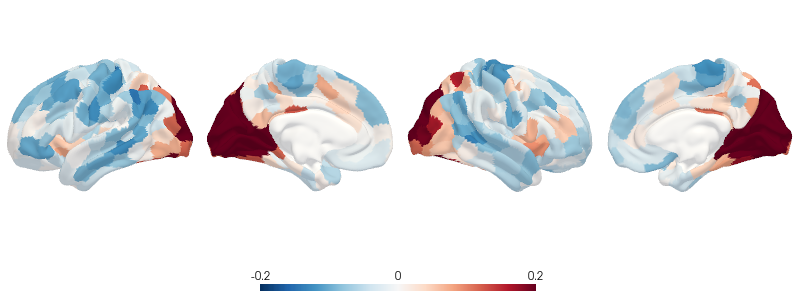

In [20]:
import warnings
import pandas as pd
import pyvista as pv
import yabplot as yab

warnings.simplefilter("ignore", pv.PyVistaDeprecationWarning)

pv.set_jupyter_backend('static')
pv.global_theme.notebook = True
pv.start_xvfb()

file_path = "/tmp/outputs_fnm/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_method-fnm_atlas-schaefer2018parcels400networks7_desc-rmap_parcelstats.tsv"

df = pd.read_csv(file_path, sep="\t", index_col=0)
values = df.values.flatten()

yab.plot_cortical(
    data=values,
    atlas='schaefer400',
    views=['left_lateral', 'left_medial', 'right_lateral', 'right_medial'],
    figsize=(800, 300),
    vminmax=(-0.2,0.2),
    cmap="RdBu_r",
    display_type="static",
)

## Run functional network mapping on multiple subjects
Lacuna supports processing multiple subjects within a single run. If the `--participant-label` flag is omitted, the pipeline automatically executes for all subjects detected in the BIDS dataset. Using `--verbose` enables inspection of the detected lesion masks.

Execution strategies are internally optimized per analysis type. For functional network mapping, subjects are processed in parallel, and multi-subject computation is implemented via vectorization. This improves throughput but has implications for memory usage.

These optimizations allow large cohorts to be processed efficiently with relatively modest computational overhead. However, RAM consumption scales with the number of subjects and should be monitored accordingly.

Internally, Lacuna loads batches of lesion masks alongside batches of resting-state fMRI data from the connectome, which together determine memory usage. Resource demands can be controlled in two ways: (1) limiting the number of lesion masks processed simultaneously via `lacuna run fnm (...) --batch-size <N>`, and (2) changing the connectome batch number during retrieval using `lacuna fetch GSP1000 (...) --batches <N>` (more batches ⟶ less size per batch ⟶ less memory demands).

For demonstration purposes, replicate the first tutorial subject to create a dataset of 40 subjects instead of 3.

In [21]:
import shutil
from pathlib import Path

tutorial_data = Path("/tmp/tutorial_bids")
tutorial_data_multiple = Path("/tmp/tutorial_bids_multiple")


src_id = "01"
src_file = tutorial_data / f"sub-{src_id}" / "ses-01" / "anat" / f"sub-{src_id}_ses-01_space-MNI152NLin6Asym_label-acuteinfarct_mask.nii.gz"

for i in range(0, 40):

    sub_id = f"{i+1:02d}"
    
    target_dir = tutorial_data_multiple / f"sub-{sub_id}" / "ses-01" / "anat"
    target_file = target_dir / f"sub-{sub_id}_ses-01_space-MNI152NLin6Asym_label-acuteinfarct_mask.nii.gz"
    
    target_dir.mkdir(parents=True, exist_ok=True)
    
    shutil.copy2(src_file, target_file)

In [22]:
!ls /tmp/tutorial_bids_multiple/

sub-01	sub-05	sub-09	sub-13	sub-17	sub-21	sub-25	sub-29	sub-33	sub-37
sub-02	sub-06	sub-10	sub-14	sub-18	sub-22	sub-26	sub-30	sub-34	sub-38
sub-03	sub-07	sub-11	sub-15	sub-19	sub-23	sub-27	sub-31	sub-35	sub-39
sub-04	sub-08	sub-12	sub-16	sub-20	sub-24	sub-28	sub-32	sub-36	sub-40


Run the analysis on the whole dataset in participant batches of n = 10.

In [23]:
!lacuna run fnm \
    /tmp/tutorial_bids_multiple/ \
    /tmp/outputs_fnm_multiple/ \
    --connectome-path /tmp/gsp1000_data/processed/ \
    --mask-space MNI152NLin6Asym \
    --batch-size 10 \
    --nprocs -1 \
    --overwrite

In [24]:
!ls /tmp/outputs_fnm_multiple

dataset_description.json  sub-06  sub-12  sub-18  sub-24  sub-30  sub-36
sub-01			  sub-07  sub-13  sub-19  sub-25  sub-31  sub-37
sub-02			  sub-08  sub-14  sub-20  sub-26  sub-32  sub-38
sub-03			  sub-09  sub-15  sub-21  sub-27  sub-33  sub-39
sub-04			  sub-10  sub-16  sub-22  sub-28  sub-34  sub-40
sub-05			  sub-11  sub-17  sub-23  sub-29  sub-35
